In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = {
    "Date": pd.date_range(start="2023-01-01", periods=100),
    "Store": np.random.randint(1, 5, 100),
    "Item": np.random.randint(1, 10, 100),
    "Sales": np.random.randint(20, 200, 100),
    "Region": np.random.choice(["North", "South", "East", "West"], 100)
}

In [4]:
df = pd.DataFrame(data)

In [5]:
print(df.head())

        Date  Store  Item  Sales Region
0 2023-01-01      4     8    191   West
1 2023-01-02      3     7     91  North
2 2023-01-03      1     7     64   West
3 2023-01-04      1     4     85  South
4 2023-01-05      1     9    118  North


In [6]:
df['Date'] = pd.to_datetime(df['Date'])
print(df.isnull().sum())
df.drop_duplicates(inplace=True)

Date      0
Store     0
Item      0
Sales     0
Region    0
dtype: int64


In [7]:
print(df['Sales'].describe())
print(df['Sales'].sum())
print(df['Sales'].mean())
print(df['Sales'].max())
print(df['Sales'].min())

count    100.000000
mean     113.940000
std       52.269662
min       20.000000
25%       73.500000
50%      113.500000
75%      163.000000
max      197.000000
Name: Sales, dtype: float64
11394
113.94
197
20


In [8]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

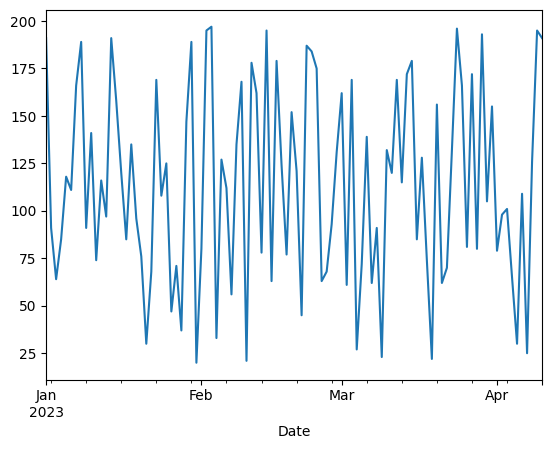

In [9]:
daily_sales = df.groupby('Date')['Sales'].sum()
plt.figure()
daily_sales.plot()
plt.show()

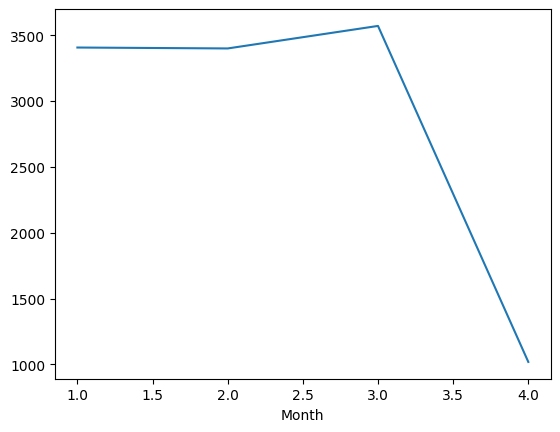

In [10]:
monthly_sales = df.groupby('Month')['Sales'].sum()
plt.figure()
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)
plt.show()

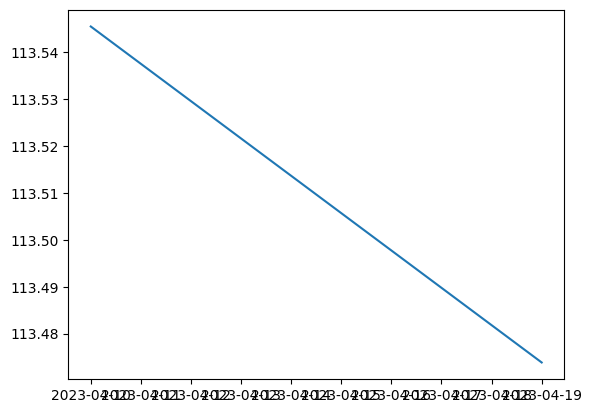

In [25]:
plt.figure()
plt.plot(future_dates, pred)
plt.show()

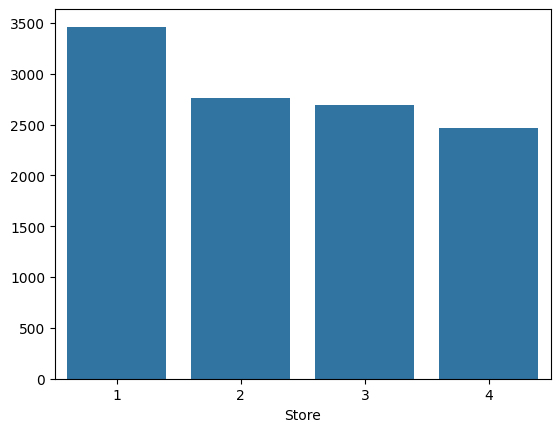

In [11]:
store_sales = df.groupby('Store')['Sales'].sum()
plt.figure()
sns.barplot(x=store_sales.index, y=store_sales.values)
plt.show()

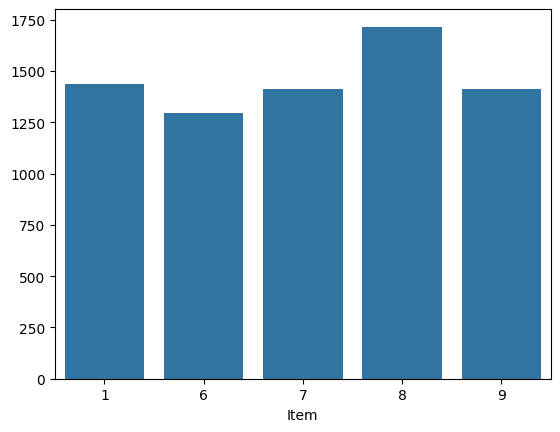

In [12]:
item_sales = df.groupby('Item')['Sales'].sum()
top_products = item_sales.sort_values(ascending=False).head(5)
plt.figure()
sns.barplot(x=top_products.index, y=top_products.values)
plt.show()

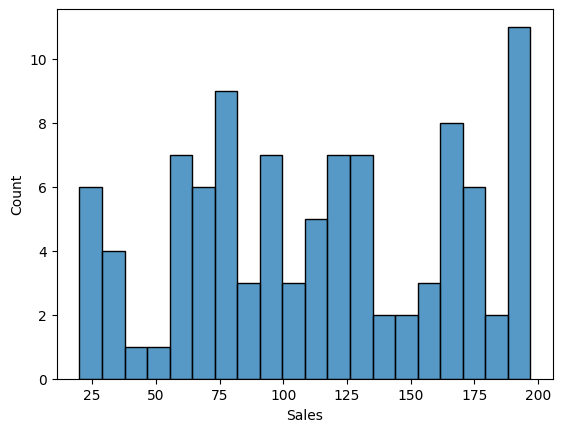

In [13]:
plt.figure()
sns.histplot(df['Sales'], bins=20)
plt.show()

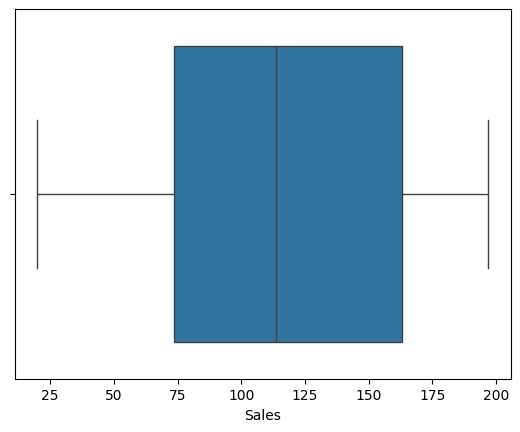

In [14]:
plt.figure()
sns.boxplot(x=df['Sales'])
plt.show()

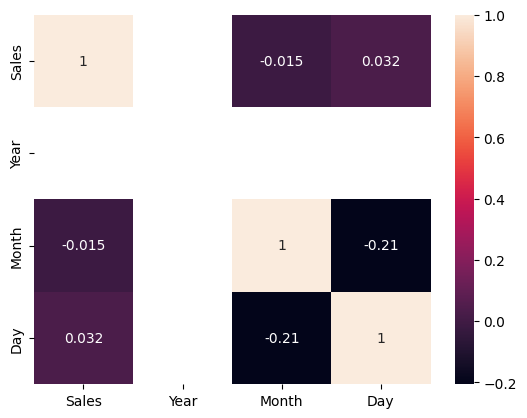

In [15]:
plt.figure()
corr = df[['Sales', 'Year', 'Month', 'Day']].corr()
sns.heatmap(corr, annot=True)
plt.show()

In [16]:
print(store_sales.idxmax())
print(store_sales.idxmin())
print(item_sales.idxmax())
print(item_sales.idxmin())
print(monthly_sales.idxmax())

1
4
8
3
3


In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
df['Date_Ordinal'] = df['Date'].map(pd.Timestamp.toordinal)

X = df[['Date_Ordinal']]
y = df['Sales']

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [22]:
future_dates = pd.date_range(start=df['Date'].max(), periods=10)
future_ord = future_dates.map(pd.Timestamp.toordinal)